In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr
import diffrax
from diffrax import ControlTerm, MultiTerm, ODETerm
import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

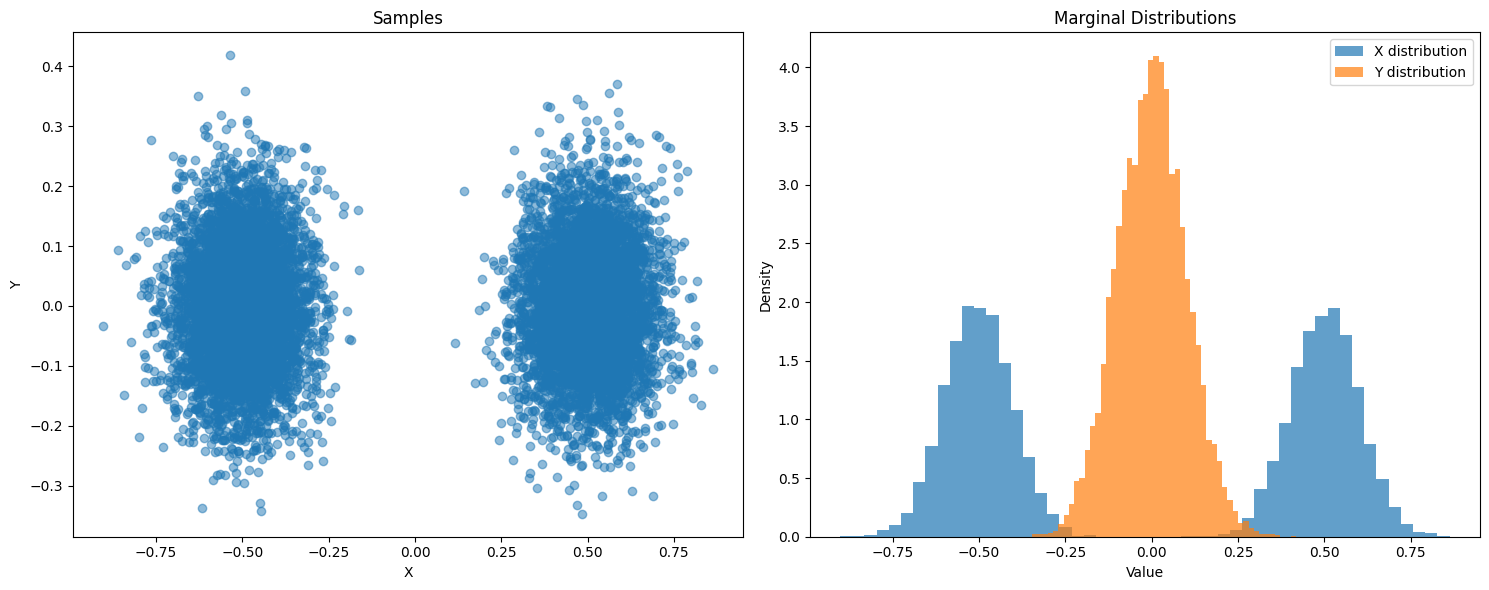

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot: Scatter plot of samples
ax1.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [4]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [5]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [6]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


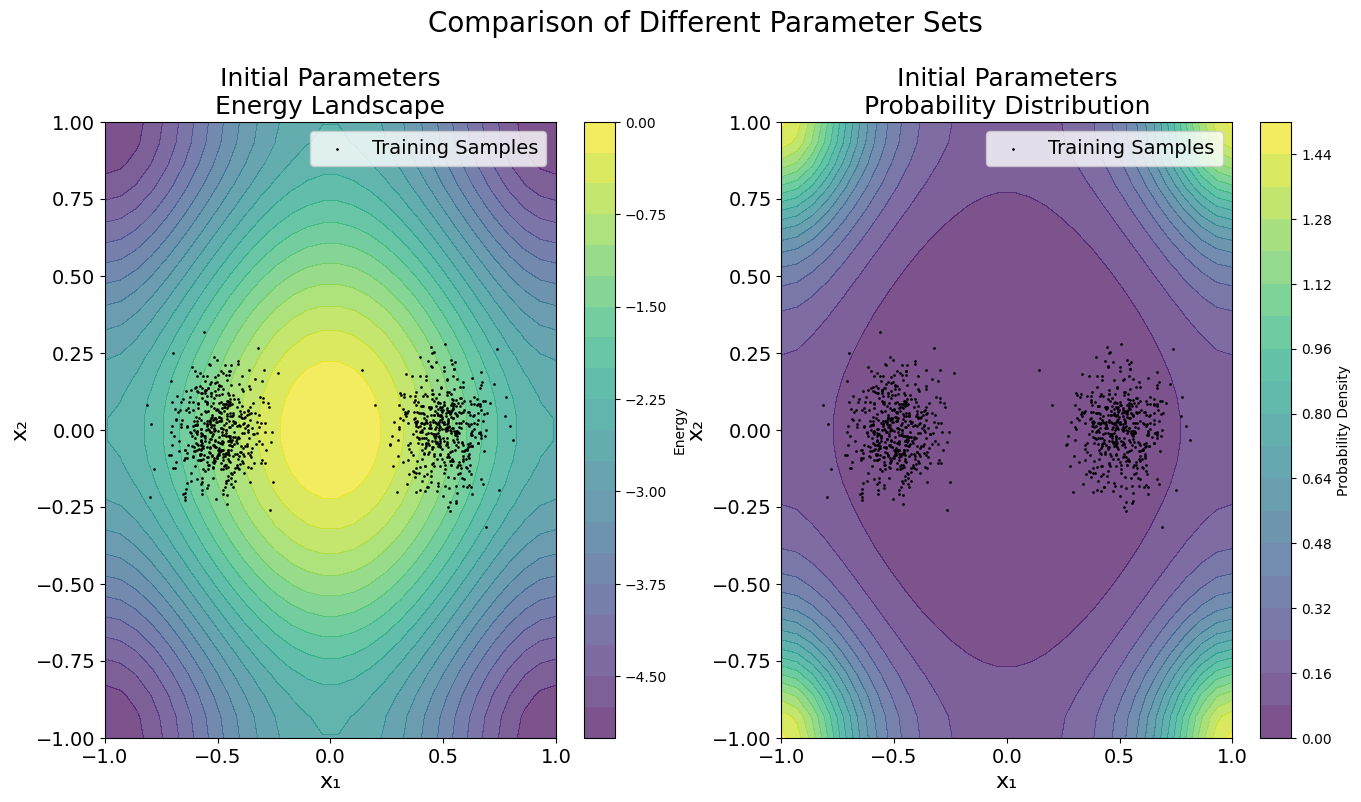

In [7]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=(16, 8),    # optional
    fontsize=16,         # optional
    suptitle="Comparison of Different Parameter Sets"  # optional
)

In [8]:
# Define optimization parameters
learning_rate = 0.01
n_epochs = 4000
batch_size = 128
loss_per_batch = setup_score_matching_loss_per_batch(energy_fn)
params_history, loss_history = run_optimization(loss_per_batch, flattened_args_initial, samples, gradient_fn_per_batch = None, key=key,batch_size=batch_size, learning_rate=learning_rate, n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01 -0.01]
Loss: 19.1641
---
Epoch 100
params:
[-0.58933181 -0.01219798  1.76740643  2.00140655  0.20491893 -0.01336791]
Loss: -12.0443
---
Epoch 200
params:
[-0.62071383  0.92731361  2.47578536  2.92509032  0.14083348  0.0212022 ]
Loss: -24.1206
---
Epoch 300
params:
[-0.7897662   1.81943422  3.1932072   3.81532303  0.13040495 -0.01513889]
Loss: -34.0689
---
Epoch 400
params:
[-1.00138526  2.66121889  3.9294449   4.65905121  0.11483261 -0.02597683]
Loss: -43.1535
---
Epoch 500
params:
[-1.23168403  3.45244407  4.68270514  5.44235562  0.11546749  0.08964102]
Loss: -53.1215
---
Epoch 600
params:
[-1.40293627  4.19537675  5.45287534  6.17624769  0.10206329  0.03526773]
Loss: -60.0177
---
Epoch 700
params:
[-1.59193655  4.87936404  6.20140356  6.83265008  0.06907082  0.03364097]
Loss: -64.1122
---
Epoch 800
params:
[-1.79961886  5.50451467  6.91800648  7.44742052  0.06097439 -0.02638878]
Loss: -68.1342
---
Epoch 900
params:
[-2.03992488e+00  6.08

In [ ]:
# # Convert histories to arrays for plotting
# slicing = 10
# params_history = jnp.array(params_history[::slicing])
# k_lin_history = jnp.zeros((len(params_history), N_osc))
# k_duff_history = jnp.zeros((len(params_history), N_osc))
# c_lin_history = jnp.zeros((len(params_history), 1))
# c_optomech_history = jnp.zeros((len(params_history), 1))

# for i in range(len(params_history)):
#     unflattened_params = unflatten(params_history[i])
#     k_lin, k_duff, c_lin, c_optomech = unflattened_params
#     k_lin_history = k_lin_history.at[i].set(k_lin)
#     k_duff_history = k_duff_history.at[i].set(k_duff)
#     c_lin_history = c_lin_history.at[i].set(c_lin)
#     c_optomech_history = c_optomech_history.at[i].set(c_optomech)

# loss_history = jnp.array(loss_history[::slicing])

# # Find index of lowest loss
# best_idx = jnp.argmin(loss_history)

# # Get parameters corresponding to lowest loss
# k_lin_best = k_lin_history[best_idx]
# k_duff_best = k_duff_history[best_idx]
# c_lin_best = c_lin_history[best_idx]
# c_optomech_best = c_optomech_history[best_idx]

# # Create tuple of best args in same structure as initial args
# args_best = (k_lin_best, k_duff_best, c_lin_best, c_optomech_best)

# # Flatten using the same unflatten function from earlier
# flattened_args_best, _ = flatten_util.ravel_pytree(args_best)

# print(f"Best loss: {loss_history[best_idx]:.4e}")
# print(f"Found at epoch: {best_idx * slicing}")


# # Create figure with 4 rows and 2 columns
# fig, axes = plt.subplots(2, 2, figsize=(6, 6))

# # Plot k_lin evolution
# for i in range(N_osc):
#     axes[0, 0].plot(k_lin_history[:, i], label=f'k_lin[{i}]')
# axes[0, 0].set_title(f'Evolution of k_lin\nBest values:\n' + 
#                      '\n'.join([f'k_lin[{i}] = {k_lin_best[i]:.3f}' 
#                                for i in range(N_osc)]))
# axes[0, 0].set_xlabel('Epoch')
# axes[0, 0].set_ylabel('Linear Strength')
# axes[0, 0].legend()
# axes[0, 0].grid(True)

# # Plot k_duff evolution
# for i in range(N_osc):
#     axes[0, 1].plot(k_duff_history[:, i], label=f'k_duff[{i}]')
# axes[0, 1].set_title(f'Evolution of k_duff\nBest values:\n' + 
#                      '\n'.join([f'k_duff[{i}] = {k_duff_best[i]:.3f}' 
#                                for i in range(N_osc)]))
# axes[0, 1].set_xlabel('Epoch')
# axes[0, 1].set_ylabel('Duffing Strength')
# axes[0, 1].legend()
# axes[0, 1].grid(True)

# # Plot c_lin and c_optomech evolution
# axes[1, 0].plot(c_lin_history, label='c_lin')
# axes[1, 0].plot(c_optomech_history, label='c_optomech')
# axes[1, 0].set_title(f'Evolution of Coupling Parameters\nBest values:\n' +
#                      f'c_lin = {c_lin_best[0]:.3f}\n' +
#                      f'c_optomech = {c_optomech_best[0]:.3f}')
# axes[1, 0].set_xlabel('Epoch')
# axes[1, 0].set_ylabel('Coupling Strength')
# axes[1, 0].legend()
# axes[1, 0].grid(True)

# # Plot loss evolution
# axes[1, 1].plot(loss_history, label='Loss')
# axes[1, 1].set_title(f'Evolution of Loss\nBest value: {loss_history[best_idx]:.3e}')
# axes[1, 1].set_xlabel('Epoch')
# axes[1, 1].set_ylabel('Loss')
# axes[1, 1].legend()
# axes[1, 1].grid(True)

# plt.tight_layout()
# plt.suptitle("CD", y=1.02)
# plt.show()

Best loss: -1.1205e+02
Found at epoch: 2800


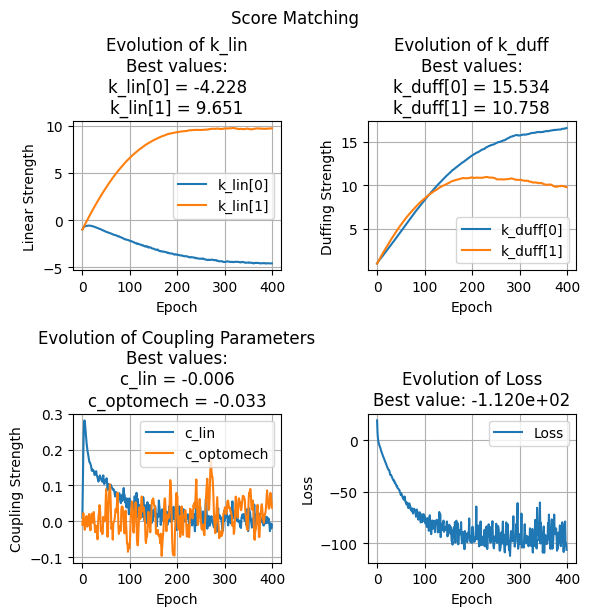

In [10]:
# For the first optimization
k_lin_best, k_duff_best, c_lin_best, c_optomech_best = plot_parameter_evolution(
    params_history=params_history,
    loss_history=loss_history,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="Score Matching"
)

In [11]:
# Define optimization parameters
learning_rate = 0.01
n_epochs = 4000
batch_size = 128
loss_per_batch = setup_score_matching_loss_per_batch(energy_fn)
key, subkey = jr.split(key)
cd1_grad = lambda params, batch: -CD1_gradient(energy_fn, batch, params, 
                            dt=0.001, D=1, key=subkey, num_noise_samples=100)

params_history_cd1, loss_history_cd1 = run_optimization(loss_per_batch, flattened_args_initial, samples, gradient_fn_per_batch = cd1_grad, key=key,batch_size=batch_size, learning_rate=learning_rate, n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 18.7214
---
Epoch 100
params:
[-0.59616496 -0.01821816  1.74800366  1.97743267  0.20835654  0.22910672]
Loss: -11.2309
---
Epoch 200
params:
[-0.62565117  0.92456787  2.4313976   2.91995117  0.1672174   0.18720541]
Loss: -23.6020
---
Epoch 300
params:
[-0.7751903   1.82123521  3.15285229  3.81116046  0.12282303  0.18327896]
Loss: -33.4218
---
Epoch 400
params:
[-0.98736959  2.6557459   3.87438273  4.63199705  0.11019912  0.23967382]
Loss: -44.3914
---
Epoch 500
params:
[-1.1694383   3.45108686  4.61478787  5.39952622  0.12329947  0.25453821]
Loss: -50.0130
---
Epoch 600
params:
[-1.3794647   4.19128891  5.32923579  6.10508797  0.08070893  0.20157785]
Loss: -57.7734
---
Epoch 700
params:
[-1.53553942  4.87986497  6.06108228  6.79080787  0.08557487  0.22662555]
Loss: -65.5669
---
Epoch 800
params:
[-1.79236695  5.50878062  6.724071    7.40152341  0.07507122  0.21872133]
Loss: -67.6276
---
Epoch 900
params:
[-1.92803789  6.105607

In [12]:
# Convert histories to arrays for plotting
slicing = 10
params_history_cd1 = jnp.array(params_history_cd1[::slicing])
k_lin_history_cd1 = jnp.zeros((len(params_history_cd1), N_osc))
k_duff_history_cd1 = jnp.zeros((len(params_history_cd1), N_osc))
c_lin_history_cd1 = jnp.zeros((len(params_history_cd1), 1))
c_optomech_history_cd1 = jnp.zeros((len(params_history_cd1), 1))

for i in range(len(params_history_cd1)):
    unflattened_params_cd1 = unflatten(params_history_cd1[i])
    k_lin_cd1, k_duff_cd1, c_lin_cd1, c_optomech_cd1 = unflattened_params_cd1
    k_lin_history_cd1 = k_lin_history_cd1.at[i].set(k_lin_cd1)
    k_duff_history_cd1 = k_duff_history_cd1.at[i].set(k_duff_cd1)
    c_lin_history_cd1 = c_lin_history_cd1.at[i].set(c_lin_cd1)
    c_optomech_history_cd1 = c_optomech_history_cd1.at[i].set(c_optomech_cd1)

loss_history_cd1 = jnp.array(loss_history_cd1[::slicing])

# Find index of lowest loss
best_idx_cd1 = jnp.argmin(loss_history_cd1)

# Get parameters corresponding to lowest loss
k_lin_best_cd1 = k_lin_history_cd1[best_idx_cd1]
k_duff_best_cd1 = k_duff_history_cd1[best_idx_cd1]
c_lin_best_cd1 = c_lin_history_cd1[best_idx_cd1]
c_optomech_best_cd1 = c_optomech_history_cd1[best_idx_cd1]

# Create tuple of best args in same structure as initial args
args_best_cd1 = (k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1)

# Flatten using the same unflatten function from earlier
flattened_args_best_cd1, _ = flatten_util.ravel_pytree(args_best_cd1)

print(f"Best loss: {loss_history_cd1[best_idx_cd1]:.4e}")
print(f"Found at epoch: {best_idx_cd1 * slicing}")

Best loss: -1.1534e+02
Found at epoch: 3420


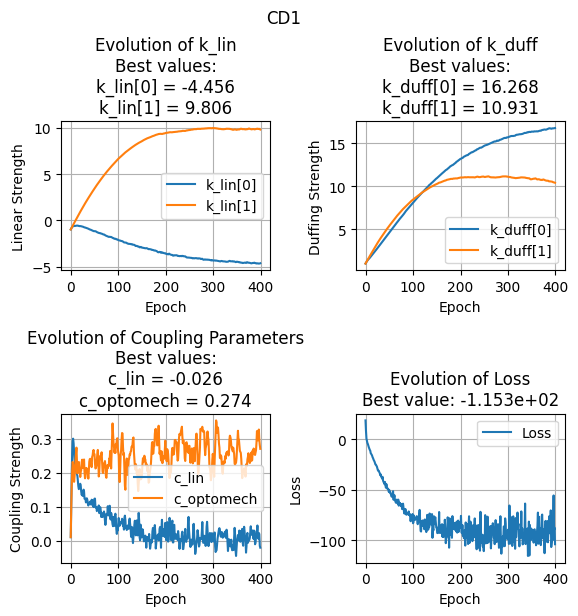

In [13]:
# Create figure with 4 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

# Plot k_lin evolution
for i in range(N_osc):
    axes[0, 0].plot(k_lin_history_cd1[:, i], label=f'k_lin[{i}]')
axes[0, 0].set_title(f'Evolution of k_lin\nBest values:\n' + 
                     '\n'.join([f'k_lin[{i}] = {k_lin_best_cd1[i]:.3f}' 
                               for i in range(N_osc)]))
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Linear Strength')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot k_duff evolution
for i in range(N_osc):
    axes[0, 1].plot(k_duff_history_cd1[:, i], label=f'k_duff[{i}]')
axes[0, 1].set_title(f'Evolution of k_duff\nBest values:\n' + 
                     '\n'.join([f'k_duff[{i}] = {k_duff_best_cd1[i]:.3f}' 
                               for i in range(N_osc)]))
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Duffing Strength')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot c_lin and c_optomech evolution
axes[1, 0].plot(c_lin_history_cd1, label='c_lin')
axes[1, 0].plot(c_optomech_history_cd1, label='c_optomech')
axes[1, 0].set_title(f'Evolution of Coupling Parameters\nBest values:\n' +
                     f'c_lin = {c_lin_best_cd1[0]:.3f}\n' +
                     f'c_optomech = {c_optomech_best_cd1[0]:.3f}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Coupling Strength')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot loss evolution
axes[1, 1].plot(loss_history_cd1, label='Loss')
axes[1, 1].set_title(f'Evolution of Loss\nBest value: {loss_history_cd1[best_idx_cd1]:.3e}')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.suptitle("CD1", y=1.02)
plt.show()

Initial Parameters probability distribution total (should be ≈ 1): 1.000000
Score Matching Best probability distribution total (should be ≈ 1): 1.000000
CD-1 Best probability distribution total (should be ≈ 1): 1.000000


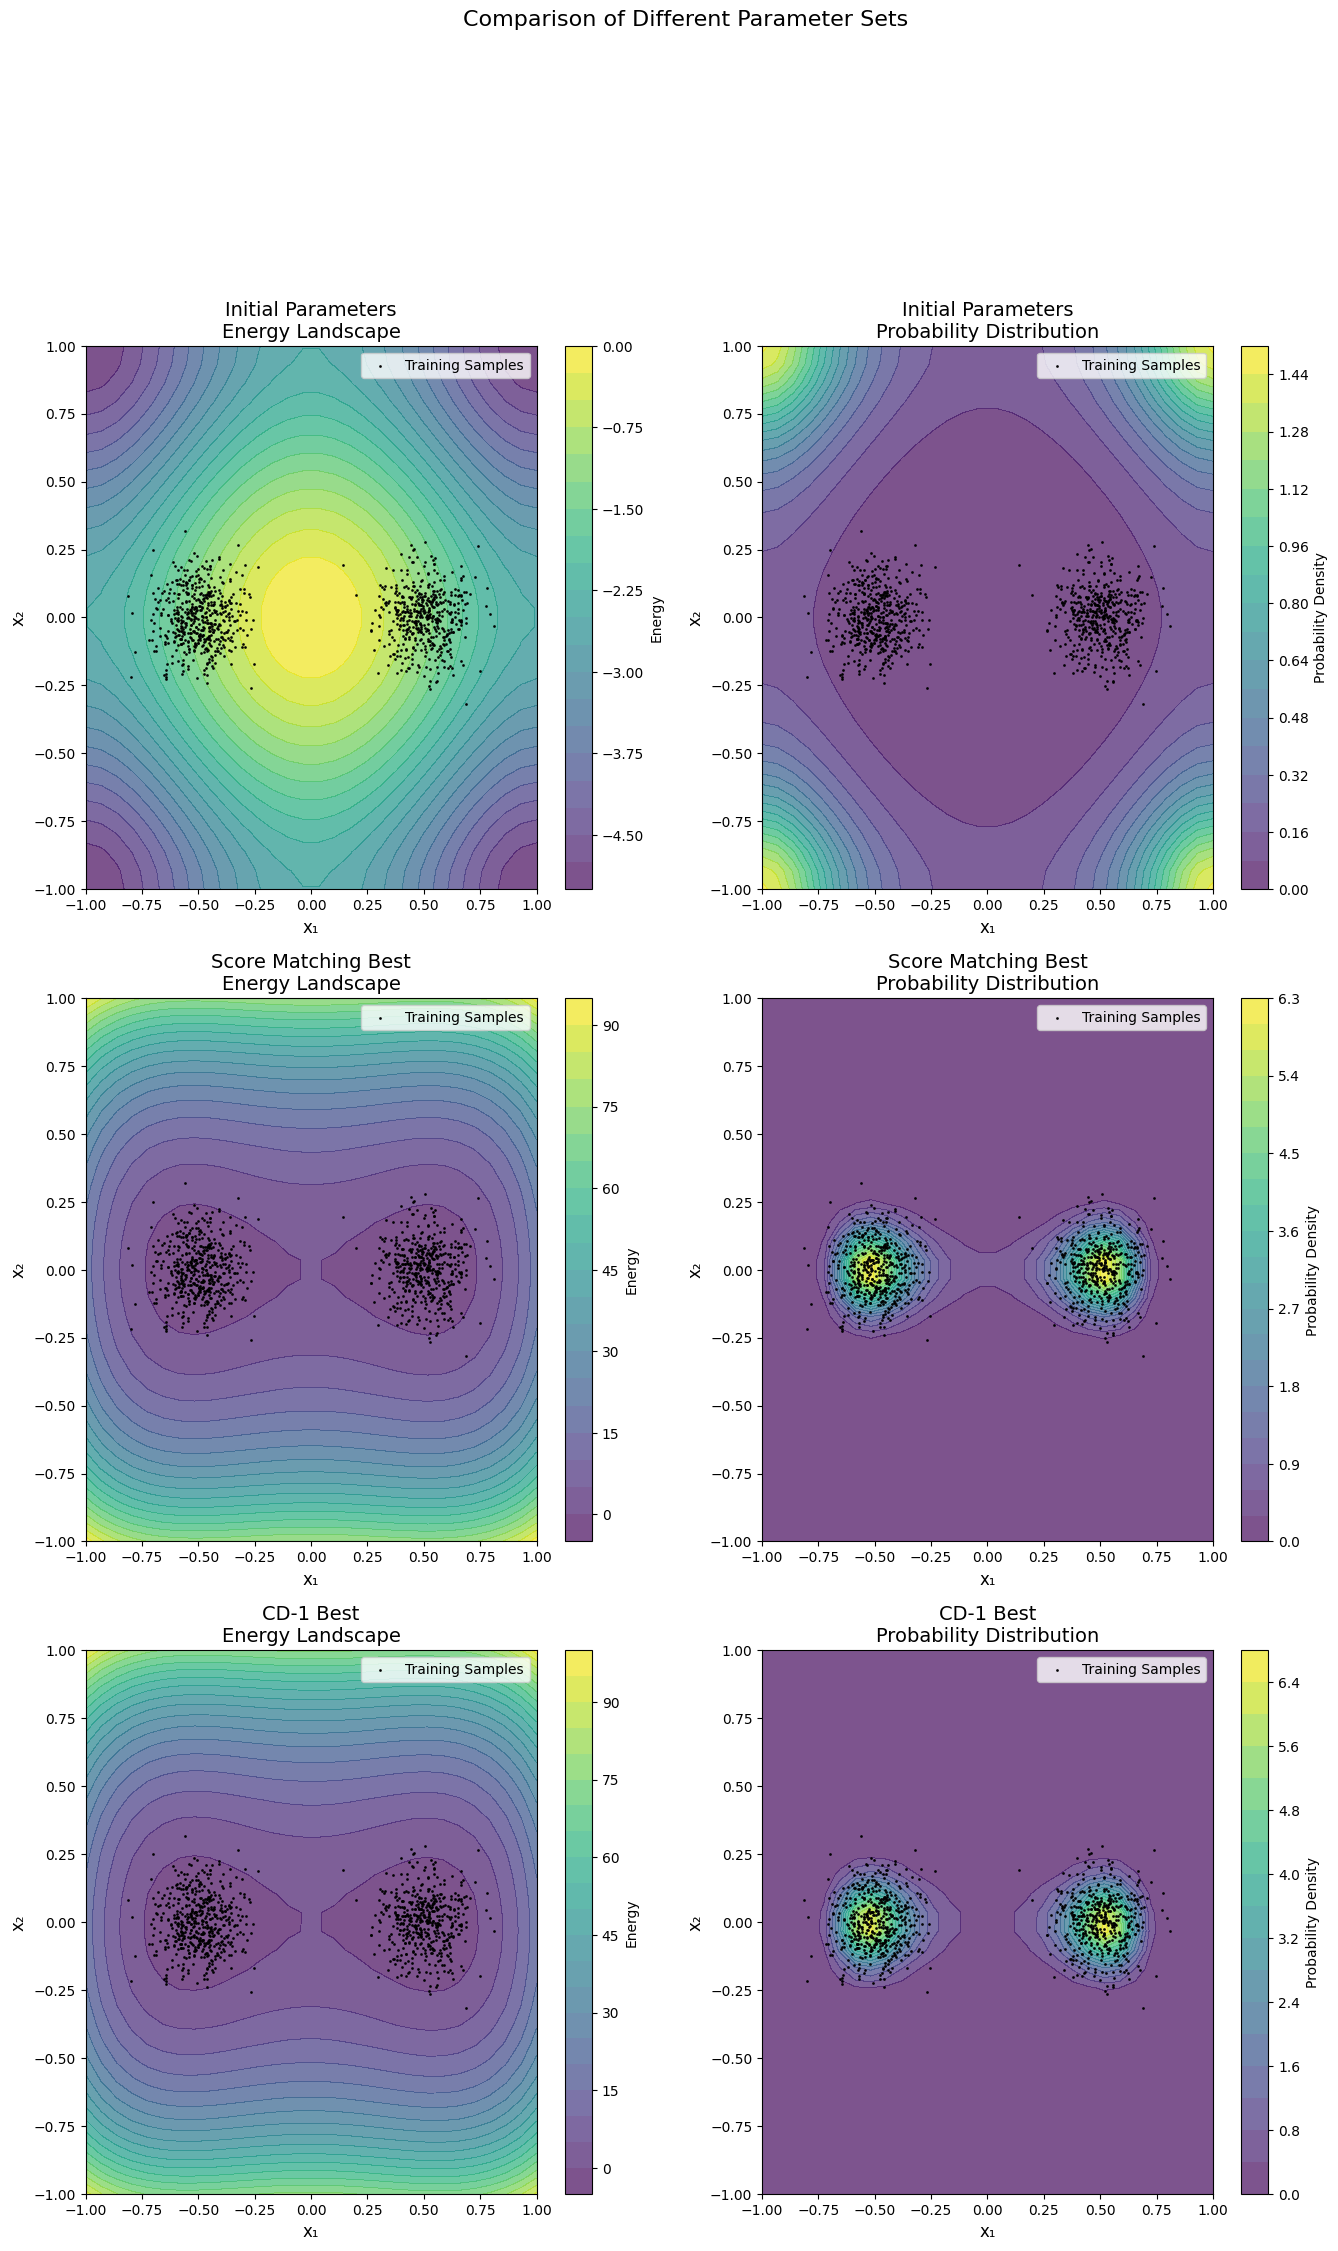

In [14]:
# Example usage:
param_list = [flattened_args_initial, flattened_args_best, flattened_args_best_cd1]
titles = ["Initial Parameters", "Score Matching Best", "CD-1 Best"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Comparison of Different Parameter Sets"  # optional
)

In [15]:
# def drift_x_fn(t, state, args):
#     """
#     Drift function for the XY model with effective temperature
#     Args:
#         t: time
#         state: array of phases (shape: N_osc)
#         args: tuple containing (W, h)
#     Returns:
#         Array of phase velocities
#     """
#     W, h = args
#     # Compute force from energy gradient
#     dE_dtheta = jax.grad(XY_energy, argnums=0)(state, W, h)
    
#     # Damping term
#     gamma = 1.0  # Damping coefficient, adjust as needed
    
#     dtheta_dt = -gamma * dE_dtheta
    
#     return dtheta_dt

# def diffusion_x_fn(t, state, args):
#     """
#     Diffusion function for the XY model with effective temperature
#     Args:
#         t: time
#         state: array of phases (shape: N_osc)
#         args: additional arguments
#     Returns:
#         Noise matrix (shape: N_osc x 1)
#     """
#     T_eff = 1.0  # Effective temperature, adjust as needed
#     gamma = 1.0  # Same damping coefficient as in drift
    
#     noise_strength = jnp.sqrt(2 * gamma * T_eff)
#     noise_matrix = jnp.eye(N_osc)
#     return noise_strength * noise_matrix



In [16]:
# # Calculate characteristic time scales
# gamma = 1.0
# T_eff = 1.0
# J = jnp.max(jnp.abs(W))  # Coupling strength

# tau_relax = 1/gamma
# tau_diffusion = gamma/(2*T_eff)

# print(f"Relaxation time scale: {tau_relax:.2f}")
# print(f"Diffusion time scale: {tau_diffusion:.2f}")

# # Set simulation time accordingly
# t0 = 0.0
# t1 = 100 * max(tau_relax, tau_diffusion)  # Simulate for 10x the longest time scale
# dt0 = min(tau_relax, tau_diffusion) / 10  # Initial time step should be smaller than fastest time scale

# print(f"\nSuggested simulation parameters:")
# print(f"Total time: {t1:.2f}")
# print(f"Initial dt: {dt0:.2f}")

# ts = jnp.linspace(t0, t1, 10000)
# dt = ts[1] - ts[0]

# y0_x = jnp.array([jnp.pi,jnp.pi])

In [17]:
# # Update shape to match number of oscillators
# w_shape = (N_osc,)  # state is just phases for each oscillator
# brownian_motion = diffrax.VirtualBrownianTree(
#     t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
# )
# terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
# saveat = diffrax.SaveAt(ts=ts)


# # sample 1000 points
# solution_x = diffrax.diffeqsolve(
#     terms_x,
#     solver=diffrax.SRA1(),
#     t0=t0,
#     t1=t1,
#     dt0=dt0,
#     y0=y0_x,
#     args=(),
#     saveat=saveat,
#     progress_meter=diffrax.TqdmProgressMeter(),
#     max_steps=1000000000,
#     stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
# )
# sde_samples_x = solution_x.ys

In [18]:
# # Calculate number of timesteps corresponding to one relaxation time
# relax_steps = int(1/(gamma * dt))

# # Thin the samples by taking every relax_steps point
# sde_samples_x = solution_x.ys[::relax_steps]
# ts = ts[::relax_steps]

In [19]:
# # Create figure with a grid of subplots
# fig = plt.figure(figsize=(16, 12))
# gs = plt.GridSpec(2, 2, height_ratios=[2, 1])

# # Top left: Phase trajectories
# ax1 = fig.add_subplot(gs[0, 0])
# # Mod 2π for time trajectories
# ax1.plot(ts, jnp.mod(sde_samples_x[:, 0], 2*jnp.pi), label='θ₁(t)')
# ax1.plot(ts, jnp.mod(sde_samples_x[:, 1], 2*jnp.pi), label='θ₂(t)')
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Phase (rad)')
# ax1.set_title('SDE Simulation: Phase vs Time')
# ax1.grid(True)
# ax1.legend()

# # Top right: Phase space with Energy contour
# ax2 = fig.add_subplot(gs[0, 1])
# contour = ax2.contourf(X1, X2, energy, levels=20, cmap='RdYlBu')
# plt.colorbar(contour, ax=ax2, label='Energy')

# # Mod 2π for phase space trajectory
# wrapped_x = jnp.mod(sde_samples_x, 2*jnp.pi)
# ax2.scatter(wrapped_x[:, 0], wrapped_x[:, 1], c='g', s=1, alpha=0.9999, label='Trajectory')
# ax2.plot(wrapped_x[0, 0], wrapped_x[0, 1], 'go', label='Start', markersize=10)


# ax2.set_xlabel('θ₁')
# ax2.set_ylabel('θ₂')
# ax2.set_title('Phase Space (Torus)')
# ax2.legend()

# # Bottom left: θ₁ histogram (mod 2π)
# ax3 = fig.add_subplot(gs[1, 0])
# ax3.hist(wrapped_x[:, 0], bins=50, density=True, alpha=0.7, label='θ₁ distribution')
# ax3.set_xlabel('θ₁')
# ax3.set_ylabel('Probability Density')
# ax3.grid(True)
# ax3.legend()

# # Bottom right: θ₂ histogram (mod 2π)
# ax4 = fig.add_subplot(gs[1, 1])
# ax4.hist(wrapped_x[:, 1], bins=50, density=True, alpha=0.7, label='θ₂ distribution')
# ax4.set_xlabel('θ₂')
# ax4.set_ylabel('Probability Density')
# ax4.grid(True)
# ax4.legend()

# plt.tight_layout()
# # Add title with parameters
# title = f'T_eff={T_eff}, γ={gamma}'
# plt.suptitle(title, y=1.02)

# plt.show()